Carga compatible con json o csv.

In [18]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def load_events(folder_path):
    all_events = []

    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)

        if file.endswith(".json"):
            with open(file_path) as f:
                data = json.load(f)
                all_events.extend(data)

        elif file.endswith(".csv"):
            df_csv = pd.read_csv(file_path)
            all_events.extend(df_csv.to_dict(orient="records"))

    df = pd.json_normalize(all_events)

    # Normalizacion comun
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'])

    df = df.sort_values("timestamp")

    return df

df = load_events("./data")
print(df)

             event_name event_type           timestamp  session_id  event_id  \
0         session_start    Generic 2026-04-19 10:00:00           1         0   
1           level_start   Gameplay 2026-04-19 10:00:05           1         1   
2        ui_interaction         UI 2026-04-19 10:00:06           1         2   
3        ui_interaction         UI 2026-04-19 10:00:07           1         3   
4            draw_start   Gameplay 2026-04-19 10:00:09           1         4   
5        ui_interaction         UI 2026-04-19 10:00:12           1         5   
6   window_backgrounded         UI 2026-04-19 10:00:20           1         6   
7   window_foregrounded         UI 2026-04-19 10:00:40           1         7   
8             level_end   Gameplay 2026-04-19 10:01:00           1         8   
9           level_start   Gameplay 2026-04-19 10:01:10           1         9   
10           draw_start   Gameplay 2026-04-19 10:01:15           1        10   
11       ui_interaction         UI 2026-

Métricas por sesión

Se representan dos métricas clave por sesión:

- Latencia de interacción válida
- Número de clics inútiles antes de la primera interacción válida

Esto permite comparar el comportamiento de los jugadores entre sesiones.

- Valores altos de latencia indican dificultad para identificar elementos interactuables.
- Un alto número de clics inútiles sugiere confusión en la interfaz.


SESSION 1
Level start: 2026-04-19 10:00:05
Click: 6.0
Click: 4.0
Click: 1.0
→ Primera válida encontrada

SESSION 2
Level start: 2026-04-19 10:02:00
Click: 2.0
→ Primera válida encontrada

Resultados:
   session_id  latency  useless_clicks
0           1      7.0               1
1           2      2.0               0


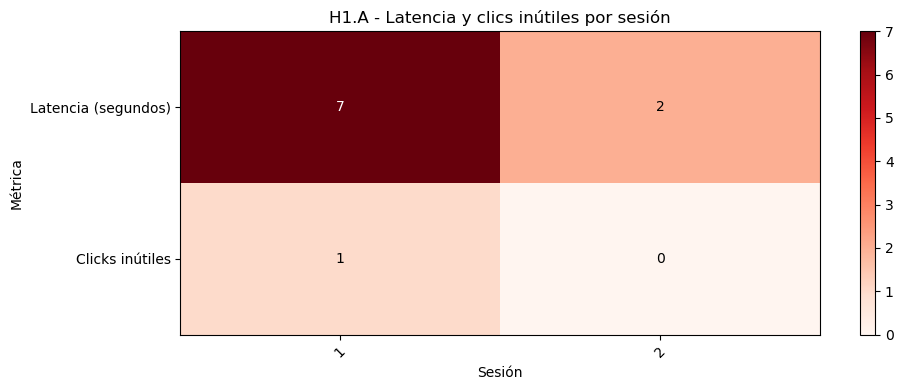

In [ ]:
valid_targets = [0,1,2]  # TRAPO, CONFIRMAR, DIBUJO
NULL_TARGET = 6

results = []

grouped = df.groupby("session_id")

for session_id, group in grouped:

    group = group.sort_values("timestamp").reset_index(drop=True)

    print("\n====================")
    print(f"SESSION {session_id}")

    # Primer level_start
    level_start = group[group["event_name"] == "level_start"]

    if level_start.empty:
        print("No level_start")
        continue

    start_time = level_start.iloc[0]["timestamp"]
    print("Level start:", start_time)

    # Interacciones posteriores
    interactions = group[group["event_name"] == "ui_interaction"]

    useless_clicks = 0
    latency = None

    for _, row in interactions.iterrows():

        # Ignorar eventos antes del level_start
        if row["timestamp"] < start_time:
            continue

        target = row["target_id"]

        print("Click:", target)

        if target == NULL_TARGET:
            useless_clicks += 1

        elif target in valid_targets:
            latency = (row["timestamp"] - start_time).total_seconds()
            print("→ Primera válida encontrada")
            break

    if latency is not None:
        results.append({
            "session_id": session_id,
            "latency": latency,
            "useless_clicks": useless_clicks
        })

# DATAFRAME FINAL
df_metrics = pd.DataFrame(results)

print("\nResultados:")
print(df_metrics)


# HEATMAP
if not df_metrics.empty:

    df_session = df_metrics.set_index("session_id")

    df_session = df_session.rename(columns={
    "latency": "Latencia (segundos)",
    "useless_clicks": "Clicks inútiles"
    })

    data = df_session.T.values

    fig, ax = plt.subplots(figsize=(10,4))

    im = ax.imshow(data, aspect='auto', cmap='Reds')

    ax.set_xticks(np.arange(len(df_session.index)))
    ax.set_yticks(np.arange(len(df_session.columns)))

    ax.set_xticklabels(df_session.index)
    ax.set_yticklabels(df_session.columns)

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):

            value = data[i, j]

            # texto blanco si el valor es alto
            color = "white" if value > data.max() / 2 else "black"

            ax.text(j, i, f"{int(value)}",
                    ha="center", va="center", color=color)

    plt.xticks(rotation=45)

    plt.colorbar(im)

    plt.title("H1.A - Latencia y clics inútiles por sesión")
    plt.xlabel("Sesión")
    plt.ylabel("Métrica")

    plt.tight_layout()
    plt.show()

else:
    print("No hay resultados")

Heatmap de interacciones y trazos por sesión

Se representan:

- Interacciones funcionales (verde)
- Interacciones decorativas (amarillo)
- Interacciones inútiles (azul)
- Inicio de trazos (rojo)

El número total de eventos por tipo se muestra en la leyenda.

Esto permite analizar no solo la interacción con la interfaz, sino también el comportamiento de dibujo del jugador.

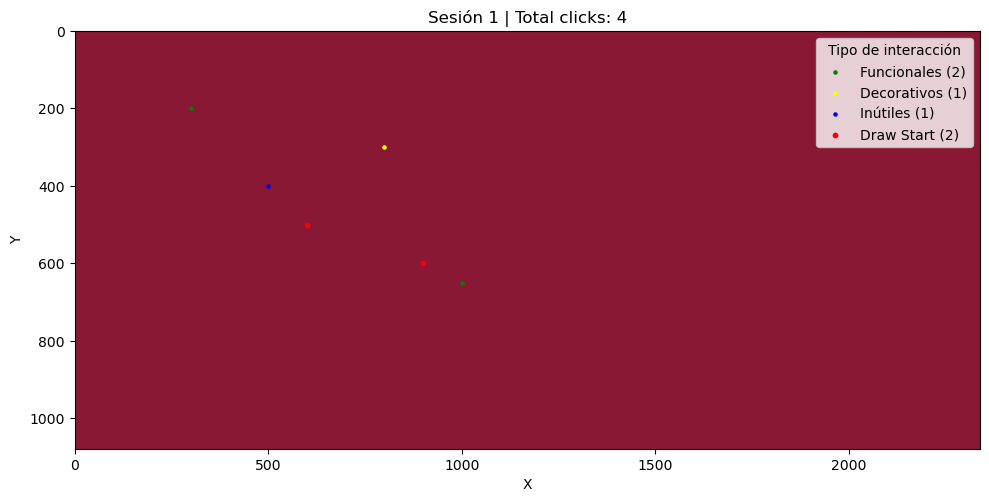

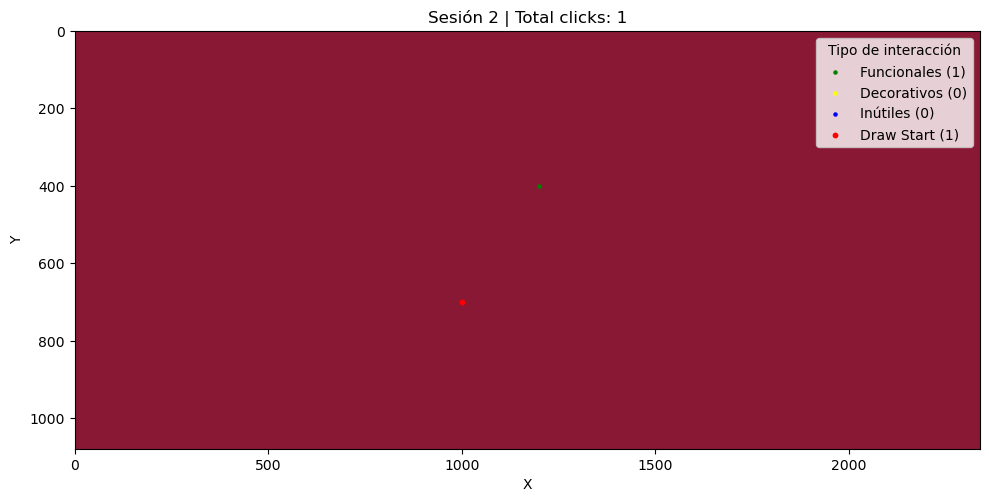

In [28]:
# Colores por tipo
colors = {
    "functional": "green",    # TRAPO, CONFIRMAR, DIBUJO
    "decorative": "yellow",      # ARAÑA, BICHILLO, OJO
    "useless": "blue",        # NULL
    "draw": "red"          # DRAW START
}

# Recorrer sesiones
for session_id in df['session_id'].dropna().unique():
    
    session_data = df[df['session_id'] == session_id]
    
    # Separar eventos
    interactions = session_data[session_data['event_name'] == "ui_interaction"]
    draw_events = session_data[session_data['event_name'] == "draw_start"]
    
    if interactions.empty and draw_events.empty:
        continue
    
    # Clasificacion
    functional = interactions[interactions['target_id'].isin([0,1,2])]
    decorative = interactions[interactions['target_id'].isin([3,4,5])]
    useless = interactions[interactions['target_id'] == 6]
    
    # Imagen fondo
    img = plt.imread("bg.png")
    
    fig, ax = plt.subplots(figsize=(10,6))
    ax.imshow(img)
    
    # Scatter UI interactions
    ax.scatter(functional['clic_pos.x'], functional['clic_pos.y'],
               c=colors["functional"], s=5,
               label=f"Funcionales ({len(functional)})")
    
    ax.scatter(decorative['clic_pos.x'], decorative['clic_pos.y'],
               c=colors["decorative"], s=5,
               label=f"Decorativos ({len(decorative)})")
    
    ax.scatter(useless['clic_pos.x'], useless['clic_pos.y'],
               c=colors["useless"], s=5,
               label=f"Inútiles ({len(useless)})")
    
    # Scatter DRAW START
    if not draw_events.empty:
        ax.scatter(draw_events['mouse_pos.x'], draw_events['mouse_pos.y'],
                   c=colors["draw"], s=10,
                   label=f"Draw Start ({len(draw_events)})")
    
    # Ajustes
    ax.legend(title="Tipo de interacción")
    ax.set_title(f"Heatmap sesión {session_id}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

    total = len(functional) + len(decorative) + len(useless)

    ax.set_title(f"Sesión {session_id} | Total clicks: {total}")
    
    #ax.invert_yaxis()
    
    plt.tight_layout()
    plt.show()

Estadísticas por cada nivel. En caso de varios resultados del mismo nivel se hace media aritmética de los mismos.

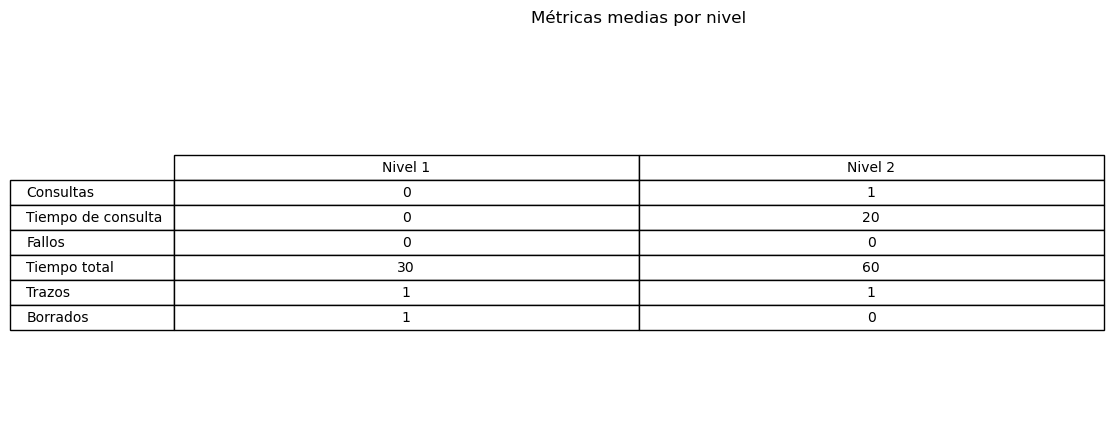

In [ ]:
valid_targets = [0, 1, 2]
erase_target = 0

results = []

# -------------------------
# RECORRER POR SESIÓN
# -------------------------
for session_id, session in df.groupby("session_id"):

    session = session.sort_values("timestamp")

    current_level = None
    level_start_time = None

    manual_count = 0
    manual_time = 0
    bg_time = None

    fail_count = 0
    draw_count = 0
    erase_count = 0

    for _, row in session.iterrows():

        event = row["event_name"]
        ts = row["timestamp"]

        # LEVEL START
        if event == "level_start":
            current_level = row["level_id"]
            level_start_time = ts

            manual_count = 0
            manual_time = 0
            bg_time = None

            fail_count = 0
            draw_count = 0
            erase_count = 0

        # UI INTERACTION
        elif event == "ui_interaction" and current_level is not None:

            tid = row["target_id"]

            if tid == erase_target:
                erase_count += 1

        # DRAW
        elif event == "draw_start" and current_level is not None:
            draw_count += 1

        # MANUAL
        elif event == "window_backgrounded" and current_level is not None:
            bg_time = ts

        elif event == "window_foregrounded" and current_level is not None:
            if bg_time is not None:
                manual_count += 1
                manual_time += (ts - bg_time).total_seconds()
                bg_time = None

        # LEVEL END
        elif event == "level_end" and current_level is not None:

            if row.get("result") == False:
                fail_count += 1
                continue

            level_time = (ts - level_start_time).total_seconds()

            results.append({
                "level_id": current_level,
                "manual_count": manual_count,
                "manual_time": manual_time,
                "fail_count": fail_count,
                "level_time": level_time,
                "draw_count": draw_count,
                "erase_count": erase_count
            })

            current_level = None


df_levels = pd.DataFrame(results)
df_mean = df_levels.groupby("level_id").mean(numeric_only=True)
df_mean = df_mean.T  # filas = métricas, columnas = niveles


df_mean.index = [
    "Consultas",
    "Tiempo de consulta",
    "Fallos",
    "Tiempo total",
    "Trazos",
    "Borrados"
]

df_mean.columns = [f"Nivel {int(float(col))}" for col in df_mean.columns]
df_display = df_mean.copy().round(0).astype(int)

# TABLA FINAL
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis("off")

table = ax.table(
    cellText=df_display.values,
    rowLabels=df_display.index,
    colLabels=df_display.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.title("Métricas medias por nivel", pad=20)
plt.show()